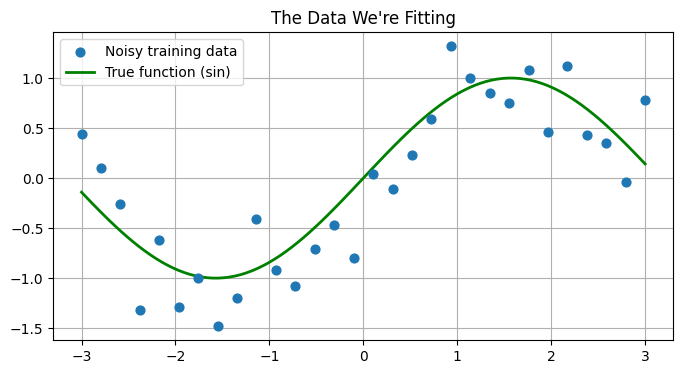

In [5]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# The core problem: a model that MEMORIZES training data
# instead of LEARNING the underlying pattern

# Analogy:
# Student who memorizes answers to past exams word for word
# vs student who learns the concepts
# First student fails new questions. Second student doesn't.

# Generate noisy data from y = sin(x)
torch.manual_seed(42)
X_train = torch.linspace(-3, 3, 30).unsqueeze(1)
y_train = torch.sin(X_train)  + 0.3 * torch.randn_like(X_train)

X_test  = torch.linspace(-3, 3, 100).unsqueeze(1)
y_test  = torch.sin(X_test)   # clean (no noise)

# Plot the data
plt.figure(figsize=(8, 4))
plt.scatter(X_train.numpy(), y_train.numpy(), s=40, label='Noisy training data', zorder=3)
plt.plot(X_test.numpy(), y_test.numpy(), 'g-', linewidth=2, label='True function (sin)')
plt.title("The Data We're Fitting")
plt.legend()
plt.grid(True)
plt.show()


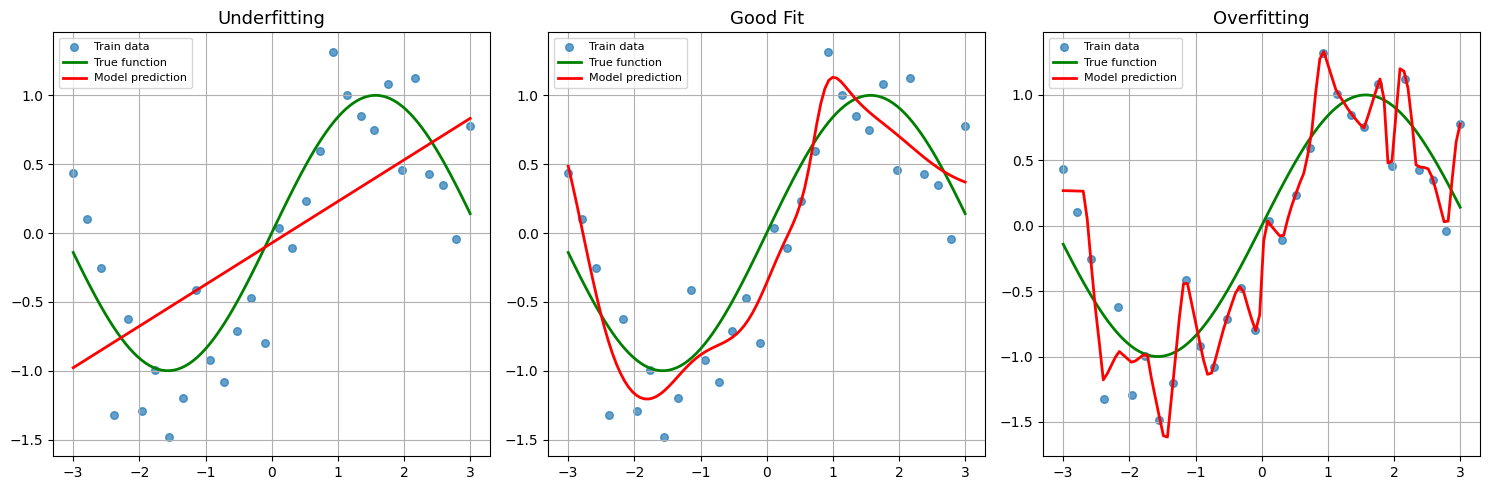

In [6]:
def train_model(model, X, y, epochs=2000, lr=0.01):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    for _ in range(epochs):
        pred = model(X)
        loss = criterion(pred, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    return model

# Underfit: too simple (1 neuron)
underfit_model = nn.Sequential(nn.Linear(1,1))

# Good fit: moderate complexity
good_model = nn.Sequential(
    nn.Linear(1, 16), nn.Tanh(),
    nn.Linear(16, 1)
)

# Overfit: too complex for the data
overfit_model = nn.Sequential(
    nn.Linear(1, 256), nn.ReLU(),
    nn.Linear(256, 256), nn.ReLU(),
    nn.Linear(256, 256), nn.ReLU(),
    nn.Linear(256, 1)
)

underfit_model = train_model(underfit_model, X_train, y_train)
good_model     = train_model(good_model,     X_train, y_train)
overfit_model  = train_model(overfit_model,  X_train, y_train, epochs=5000)

# Plot all three
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, model, title in zip(axes,
    [underfit_model, good_model, overfit_model],
    ['Underfitting', 'Good Fit', 'Overfitting']):

    with torch.no_grad():
        pred = model(X_test)

    ax.scatter(X_train.numpy(), y_train.numpy(), s=30, alpha=0.7, label='Train data')
    ax.plot(X_test.numpy(), y_test.numpy(),  'g-', linewidth=2, label='True function')
    ax.plot(X_test.numpy(), pred.numpy(),    'r-', linewidth=2, label='Model prediction')
    ax.set_title(title, fontsize=13)
    ax.legend(fontsize=8)
    ax.grid(True)

plt.tight_layout()
plt.show()


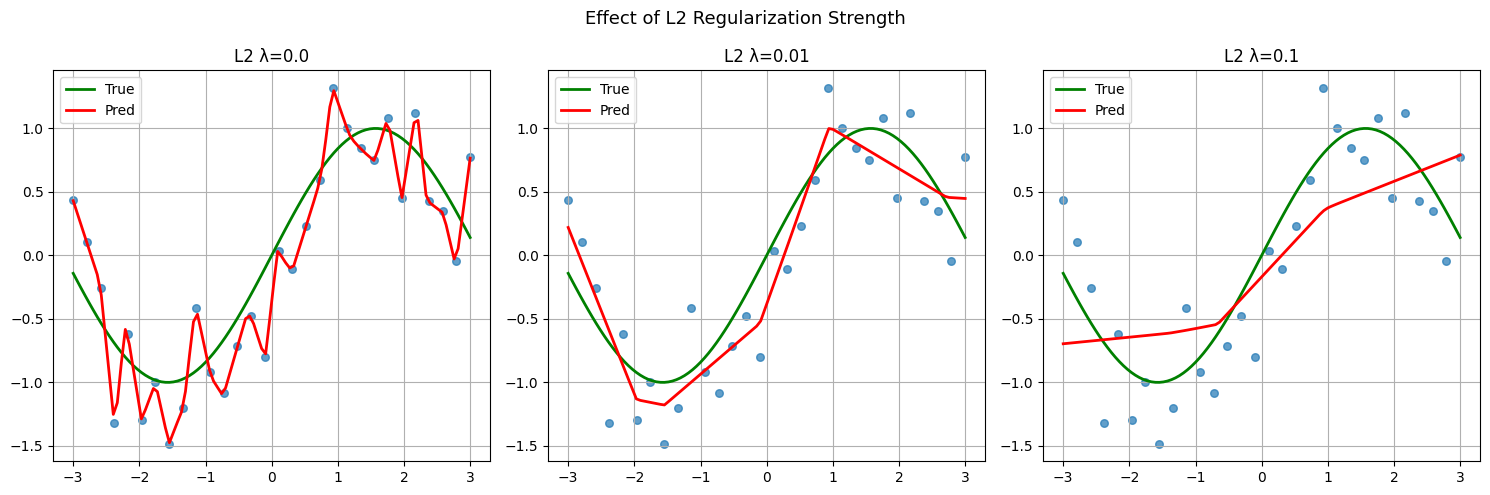

In [7]:
# L2 regularization: adds penalty for large weights to the loss
# Loss_total = Loss_original + λ * sum(w²)
# Effect: pushes weights toward zero → simpler model → less overfitting

def train_with_l2(l2_lambda, epochs=5000):
    model     = nn.Sequential(
        nn.Linear(1, 256), nn.ReLU(),
        nn.Linear(256, 256), nn.ReLU(),
        nn.Linear(256, 1)
    )
    # weight_decay IS L2 regularization in PyTorch optimizers
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01,
                                  weight_decay=l2_lambda)
    criterion = nn.MSELoss()

    for _ in range(epochs):
        pred = model(X_train)
        loss = criterion(pred, y_train)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    return model

# Comparing different λ values
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
lambdas   = [0.0, 0.01, 0.1]

for ax, lam in zip(axes, lambdas):
    model = train_with_l2(lam)
    with torch.no_grad():
        pred = model(X_test)

    ax.scatter(X_train.numpy(), y_train.numpy(), s=30, alpha=0.7)
    ax.plot(X_test.numpy(), y_test.numpy(), 'g-', linewidth=2, label='True')
    ax.plot(X_test.numpy(), pred.numpy(),   'r-', linewidth=2, label='Pred')
    ax.set_title(f"L2 λ={lam}")
    ax.legend()
    ax.grid(True)

plt.suptitle("Effect of L2 Regularization Strength", fontsize=13)
plt.tight_layout()
plt.show()


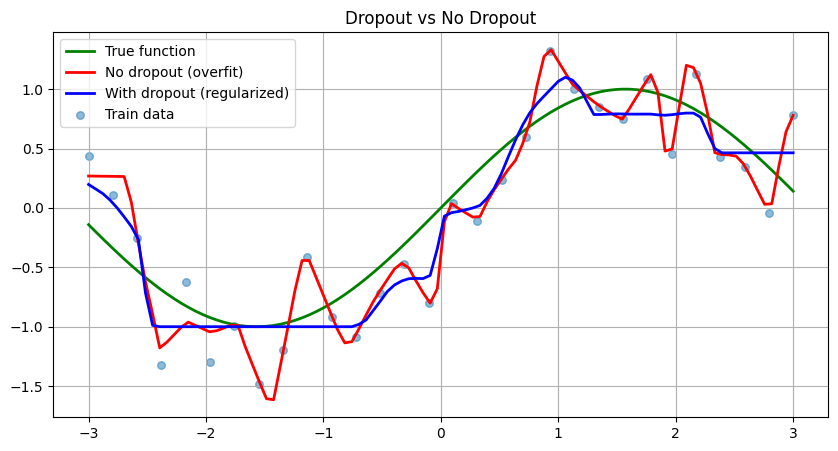

In [8]:
# Dropout: randomly zeros out neurons during training
# Effect: forces network to learn REDUNDANT representations
#         no single neuron can be relied on → more robust

class NetWithDropout(nn.Module):
    def __init__(self, dropout_rate):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),    # ← kills dropout_rate% of neurons randomly
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(256, 1)
        )

    def forward(self, x):
        return self.net(x)

# CRITICAL: Dropout behaves differently in train vs eval mode
model_dropout = NetWithDropout(0.5)
optimizer     = torch.optim.Adam(model_dropout.parameters(), lr=0.01)
criterion     = nn.MSELoss()

for epoch in range(5000):
    model_dropout.train()    # dropout is ACTIVE
    pred = model_dropout(X_train)
    loss = criterion(pred, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

# Evaluate with dropout OFF
model_dropout.eval()         # dropout is INACTIVE
with torch.no_grad():
    pred_dropout = model_dropout(X_test)

# Compare: overfit (no dropout) vs regularized (with dropout)
plt.figure(figsize=(10, 5))
with torch.no_grad():
    pred_overfit = overfit_model(X_test)

plt.plot(X_test.numpy(), y_test.numpy(),       'g-', linewidth=2, label='True function')
plt.plot(X_test.numpy(), pred_overfit.numpy(), 'r-', linewidth=2, label='No dropout (overfit)')
plt.plot(X_test.numpy(), pred_dropout.numpy(), 'b-', linewidth=2, label='With dropout (regularized)')
plt.scatter(X_train.numpy(), y_train.numpy(), s=30, alpha=0.5, label='Train data')
plt.title("Dropout vs No Dropout")
plt.legend()
plt.grid(True)
plt.show()


In [9]:
# Batch Norm: normalizes layer inputs within each mini-batch
# Effect: stabilizes training, allows higher learning rates,
#         acts as mild regularizer

class NetWithBatchNorm(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 256),
            nn.BatchNorm1d(256),    # ← normalize 256 features across batch
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.net(x)

# Key behaviors of BatchNorm:
# During TRAINING: normalizes using batch mean & std
# During EVAL:     uses running mean & std accumulated during training
# This is another reason model.train() / model.eval() matters!

model_bn = NetWithBatchNorm()
print(model_bn)
print(f"\nParameters: {sum(p.numel() for p in model_bn.parameters()):,}")

# BatchNorm adds learnable parameters (gamma, beta) per feature
# These let the network "undo" normalization if needed


NetWithBatchNorm(
  (net): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=10, bias=True)
  )
)

Parameters: 235,914


In [10]:
# Print a summary of when to use each technique
summary = """
REGULARIZATION TECHNIQUES SUMMARY
===================================

Technique     | What it does              | When to use
─────────────────────────────────────────────────────────
L2/Weight     | Penalizes large weights   | Almost always
Decay         | → simpler model           | Start with 1e-4

Dropout       | Randomly zeros neurons    | Fully connected layers
              | → redundant learning      | Rate: 0.2-0.5

Batch Norm    | Normalizes layer inputs   | Deep networks
              | → stable training         | Before activation fn

Early Stop    | Stops when val loss rises | Always in practice
              | → prevents late overfit   | Patience: 5-10 epochs

Data Aug      | Artificially expands data | Image tasks esp.
              | → more diverse training   | (Coming in Phase 2)
"""
print(summary)


REGULARIZATION TECHNIQUES SUMMARY

Technique     | What it does              | When to use
─────────────────────────────────────────────────────────
L2/Weight     | Penalizes large weights   | Almost always
Decay         | → simpler model           | Start with 1e-4

Dropout       | Randomly zeros neurons    | Fully connected layers
              | → redundant learning      | Rate: 0.2-0.5

Batch Norm    | Normalizes layer inputs   | Deep networks
              | → stable training         | Before activation fn

Early Stop    | Stops when val loss rises | Always in practice
              | → prevents late overfit   | Patience: 5-10 epochs

Data Aug      | Artificially expands data | Image tasks esp.
              | → more diverse training   | (Coming in Phase 2)

